# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [1]:
# Import standard libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pubchempy as pcp
import tarfile
import re

from sklearn.preprocessing import StandardScaler
from statsmodels.api import add_constant, OLS, Logit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import statsmodels.api as sm
from sklearn.metrics import balanced_accuracy_score

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs import ConvertToNumpyArray
import umap.umap_ as umap


/Users/yijianzong/opt/anaconda3/envs/tb_ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load training data
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
print("Shape of the master file:", master_file.shape)
master_file.head()

Shape of the master file: (48152, 114)


/var/folders/pp/jcwfn_w55v39gn9_lbws6_fw0000gn/T/ipykernel_79270/3102753570.py:2: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.1080G>A,bacA_c.1080G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [3]:
# check distribution of WHO grades
print(master_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(master_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


In [8]:
# Load supporting data
cryptic = pd.read_parquet("./cryptic_consortium_data/data/cryptic_consortium_to_who.parquet")
genomic = pd.read_csv("WHO-UCN-TB-2023.7-eng_genomic_coordinates.txt", sep="\t")

def normalize_variant(s):
    if pd.isna(s):
        return None
    return (
        str(s)
        .strip()
        .replace(" ", "")
        .lower()
    )

cryptic["variant"] = cryptic["variant"].astype(str).str.strip()
genomic["variant"] = genomic["variant"].astype(str).str.strip()

cryptic["variant_norm"] = cryptic["variant"].apply(normalize_variant)
genomic["variant_norm"] = genomic["variant"].apply(normalize_variant)

# Let's take a look at the data
print("Shape of the genomic file:", genomic.shape)
print(np.unique(genomic['variant']))
genomic.head()

Shape of the genomic file: (144964, 6)
['PPE35_c.-108A>G' 'PPE35_c.-110G>A' 'PPE35_c.-112T>C' ...
 'whiB7_p.Val6Phe' 'whiB7_p.Val91Gly' 'whiB7_p.Val91Ile']


,variant,chromosome,position,reference_nucleotide,alternative_nucleotide,variant_norm
0,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CA,dnaa_p.asp3ala
1,dnaA_p.Asp3Ala,NC_000962.3,8,A,C,dnaa_p.asp3ala
2,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CC,dnaa_p.asp3ala
3,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CG,dnaa_p.asp3ala
4,dnaA_p.Asp4His,NC_000962.3,10,G,C,dnaa_p.asp4his


In [9]:
print(cryptic.shape)
print(cryptic.sort_values("variant").head())
print(cryptic.columns.to_list())

(722614, 12)
           GENE MUTATION  GENE_POSITION  REF  ALT DRUG     DRUG_NAME  \
184585  35kd_ag    A149A          149.0  gcc  gct  KAN     KANAMYCIN   
485552  35kd_ag    A149A          149.0  gcc  gct  DLM     DELAMANID   
94018   35kd_ag    A149A          149.0  gcc  gct  INH     ISONIAZID   
31611   35kd_ag    A149A          149.0  gcc  gct  MXF  MOXIFLOXACIN   
231355  35kd_ag    A149A          149.0  gcc  gct  LEV  LEVOFLOXACIN   

        mean_log2mic  median_log2mic  count              variant  \
184585      0.625000            1.00      8  35kd_ag_p.Ala149Ala   
485552     -6.567143           -6.97      7  35kd_ag_p.Ala149Ala   
94018      -0.570000            0.68      8  35kd_ag_p.Ala149Ala   
31611      -3.302500           -3.06      8  35kd_ag_p.Ala149Ala   
231355     -2.272500           -2.00      8  35kd_ag_p.Ala149Ala   

               variant_norm  
184585  35kd_ag_p.ala149ala  
485552  35kd_ag_p.ala149ala  
94018   35kd_ag_p.ala149ala  
31611   35kd_ag_p.ala149a

In [10]:
merged_file = master_file.merge(
    genomic[[
        "variant_norm",
        "variant",
        "chromosome",
        "position",
        "reference_nucleotide",
        "alternative_nucleotide"
    ]],
    on="variant",
    how="left"
)


merged_file.head()

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,variant_norm,chromosome,position,reference_nucleotide,alternative_nucleotide
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,no,NaN,NaN,0,baca_c.102g>a,NC_000962.3,2064627.0,C,T
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,no,NaN,NaN,0,baca_c.1044g>a,NC_000962.3,2063685.0,C,T
2,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,no,NaN,NaN,0,baca_c.1044g>a,NC_000962.3,2063685.0,CAA,TAG
3,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,no,NaN,NaN,0,baca_c.105c>g,NC_000962.3,2064624.0,G,C
4,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,no,NaN,NaN,0,baca_c.1065t>g,NC_000962.3,2063658.0,TAATCGA,CAACCGC


In [11]:
# normalize drug names in cryptic and master file to merge on drug names as well
def normalize_drug_name(s):
    if pd.isna(s):
        return None
    return (
        str(s)
        .strip()
        .lower()
    )
cryptic["drug_norm"] = cryptic["DRUG_NAME"].apply(normalize_drug_name)
merged_file["drug_norm"] = merged_file["drug"].apply(normalize_drug_name)

merged_file_cryptic = merged_file.merge(
    cryptic[[
        "variant_norm",
        "drug_norm",
        "DRUG_NAME",
        "mean_log2mic",
        "median_log2mic",
        "count"
    ]],
    on=["variant_norm", "drug_norm"],
    how="left"
)

merged_file_cryptic.head()

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,variant_norm,chromosome,position,reference_nucleotide,alternative_nucleotide,drug_norm,DRUG_NAME,mean_log2mic,median_log2mic,count
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,baca_c.102g>a,NC_000962.3,2064627.0,C,T,amikacin,NaN,NaN,NaN,NaN
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,baca_c.1044g>a,NC_000962.3,2063685.0,C,T,amikacin,NaN,NaN,NaN,NaN
2,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,baca_c.1044g>a,NC_000962.3,2063685.0,CAA,TAG,amikacin,NaN,NaN,NaN,NaN
3,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,baca_c.105c>g,NC_000962.3,2064624.0,G,C,amikacin,NaN,NaN,NaN,NaN
4,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,baca_c.1065t>g,NC_000962.3,2063658.0,TAATCGA,CAACCGC,amikacin,NaN,NaN,NaN,NaN


In [12]:
cryptic_variant_fallback = (
    cryptic
    .groupby("variant_norm", as_index=False)
    .agg(
        mean_log2mic_variant=("mean_log2mic", "mean"),
        median_log2mic_variant=("median_log2mic", "median"),
        count_variant=("count", "sum")
    )
)

merged_file_cryptic = merged_file_cryptic.merge(
    cryptic_variant_fallback,
    on="variant_norm",
    how="left"
)

merged_file_cryptic["has_exact_mic"] = merged_file_cryptic["mean_log2mic"].notna().astype(int)
merged_file_cryptic["has_variant_mic"] = merged_file_cryptic["mean_log2mic_variant"].notna().astype(int)

merged_file_cryptic["mean_log2mic_final"] = (
    merged_file_cryptic["mean_log2mic"]
    .fillna(merged_file_cryptic["mean_log2mic_variant"])
    .fillna(0)
)

merged_file_cryptic["mic_count_final"] = (
    merged_file_cryptic["count"]
    .fillna(merged_file_cryptic["count_variant"])
    .fillna(0)
)

In [13]:
print("Rows with MIC:", merged_file_cryptic["mean_log2mic"].notna().sum())
print("Total rows:", len(merged_file_cryptic))

Rows with MIC: 5676
Total rows: 203424


In [14]:
# Drop some initial columns that we won't be using, many which are text results and would be difficult to use for models
keep_columns = [
    "mutation",
    "drug",
    "gene",
    "FINAL CONFIDENCE GRADING",

    "variant",
    "chromosome",
    "position",
    "reference_nucleotide",
    "alternative_nucleotide",

    "PPV_DATASET ALL",

    # NEW MIC FEATURES
    "mean_log2mic_final",
    "mic_count_final",
    "has_exact_mic",
    "has_variant_mic"
]
merged_file_cryptic = merged_file_cryptic.copy()
merged_file_cryptic = merged_file_cryptic[keep_columns]
merged_file_cryptic.head()

,mutation,drug,gene,FINAL CONFIDENCE GRADING,variant,chromosome,position,reference_nucleotide,alternative_nucleotide,PPV_DATASET ALL,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic
0,c.102G>A,Amikacin,bacA,4) Not assoc w R - Interim,bacA_c.102G>A,NC_000962.3,2064627.0,C,T,0.000000,0.0,0.0,0,0
1,c.1044G>A,Amikacin,bacA,5) Not assoc w R,bacA_c.1044G>A,NC_000962.3,2063685.0,C,T,0.075644,0.0,0.0,0,0
2,c.1044G>A,Amikacin,bacA,5) Not assoc w R,bacA_c.1044G>A,NC_000962.3,2063685.0,CAA,TAG,0.075644,0.0,0.0,0,0
3,c.105C>G,Amikacin,bacA,4) Not assoc w R - Interim,bacA_c.105C>G,NC_000962.3,2064624.0,G,C,0.000000,0.0,0.0,0,0
4,c.1065T>G,Amikacin,bacA,4) Not assoc w R - Interim,bacA_c.1065T>G,NC_000962.3,2063658.0,TAATCGA,CAACCGC,0.000000,0.0,0.0,0,0


In [15]:
merged_file_cryptic["PPV_DATASET ALL"].describe()

count    203408.000000
mean          0.277983
std           0.386748
min           0.000000
25%           0.000000
50%           0.000000
75%           0.500000
max           1.000000
Name: PPV_DATASET ALL, dtype: float64

In [16]:
merged_file_cryptic["ppv"] = merged_file_cryptic["PPV_DATASET ALL"]
merged_df = merged_file_cryptic.drop(columns=["PPV_DATASET ALL"])
merged_file_cryptic = merged_file_cryptic[merged_file_cryptic["ppv"] > 0].copy()

In [17]:
# check distribution of WHO grades
print(merged_file_cryptic["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(merged_file_cryptic["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                  10145
2) Assoc w R - Interim        15205
3) Uncertain significance     54344
4) Not assoc w R - Interim     8609
5) Not assoc w R               1633
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.112802
2) Assoc w R - Interim        0.169065
3) Uncertain significance     0.604252
4) Not assoc w R - Interim    0.095724
5) Not assoc w R              0.018157
Name: proportion, dtype: float64


In [18]:
# Drop the uncertain resistance
df = merged_file_cryptic.copy()
df = df[df['FINAL CONFIDENCE GRADING'] != '3) Uncertain significance']

# check distribution of WHO grades
print(df["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(df["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index())

def make_binary_label(data):
    if "1) Assoc w R" in data or "2) Assoc w R - Interim" in data:
        return 1
    elif "4) Not assoc w R - Interim" in data or "5) Not assoc w R" in data:
        return 0
    return None

df["resistant"] = df["FINAL CONFIDENCE GRADING"].apply(make_binary_label)
df_model = df.dropna(subset=["resistant"]).copy()

print(df_model["resistant"].value_counts())

df_model = df_model.drop(columns=["FINAL CONFIDENCE GRADING"])


FINAL CONFIDENCE GRADING
1) Assoc w R                  10145
2) Assoc w R - Interim        15205
4) Not assoc w R - Interim     8609
5) Not assoc w R               1633
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.285036
2) Assoc w R - Interim        0.427203
4) Not assoc w R - Interim    0.241880
5) Not assoc w R              0.045881
Name: proportion, dtype: float64
resistant
1    25350
0    10242
Name: count, dtype: int64


In [19]:
# Splitting the mutation column up to make fewer columns when one hot encoding
import re
# Amino acid 3-letter to 1-letter code map
AA_MAP = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Gln': 'Q', 'Glu': 'E', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V',
    'Ter': '*', 'Stop': '*'
}

def parse_aa(code):
    """Convert 3-letter amino acid code to 1-letter, or return as-is if already 1-letter or stop."""
    if code == '*':
        return '*'
    return AA_MAP.get(code, code)


def extract_features(mutation):

    PREFIX = r'[cn]\.'

    # -------------------------
    # PROTEIN-LEVEL: p. notation
    # -------------------------

    # Stop extension: p.Ter559Glnext*? or p.Ter559ext*? or p.Ter628Serext*?
    p_ext = re.match(r'p\.Ter(\d+)([A-Z][a-z]{2})?ext\*\?$', mutation)
    if p_ext:
        pos, alt_aa = p_ext.groups()
        return {'mut_type': 'extension', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': '*', 'alt': parse_aa(alt_aa) if alt_aa else None}

    # Stop codon unknown delins: p.Ter839delins???
    p_ter_delins = re.match(r'p\.Ter(\d+)delins\?+$', mutation)
    if p_ter_delins:
        pos = p_ter_delins.group(1)
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': '*', 'alt': None}

    # Frameshift: p.Asp379fs
    p_fs = re.match(r'p\.([A-Z][a-z]{2})(\d+)fs$', mutation)
    if p_fs:
        ref_aa, pos = p_fs.groups()
        return {'mut_type': 'frameshift', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Stop/nonsense: p.Trp122*
    p_stop = re.match(r'p\.([A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_stop:
        ref_aa, pos = p_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': '*'}

    # Malformed nonsense: p.TrpLeu266*
    p_malformed_stop = re.match(r'p\.([A-Z][a-z]{2}[A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_malformed_stop:
        ref_aa, pos = p_malformed_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': None, 'alt': '*'}

    # Uncertain: p.Met1?
    p_uncertain = re.match(r'p\.([A-Z][a-z]{2})(\d+)\?$', mutation)
    if p_uncertain:
        ref_aa, pos = p_uncertain.groups()
        return {'mut_type': 'uncertain', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Single AA deletion: p.Leu95del
    p_single_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_single_del:
        ref_aa, pos = p_single_del.groups()
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA deletion: p.Val3_Thr4del
    p_range_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_range_del:
        ref_aa, start, _, end = p_range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA duplication: p.His68_Leu70dup
    p_range_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_range_dup:
        ref_aa, start, _, end = p_range_dup.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA insertion: p.Val389_Asp390insGly  (one or more 3-letter AA codes)
    p_range_ins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)ins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_ins:
        ref_aa, start, _, end, ins_aas = p_range_ins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA delins: p.Pro14_Val301delinsLeu or p.Leu443_Lys446delinsProGln
    p_range_delins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)delins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_delins:
        ref_aa, start, _, end, ins_aas = p_range_delins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Missense: p.Ala152Val  (must come after all range patterns)
    p_missense = re.match(r'p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})$', mutation)
    if p_missense:
        ref_aa, pos, alt_aa = p_missense.groups()
        return {'mut_type': 'missense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': parse_aa(alt_aa)}

    # Duplication single AA: p.Ala285dup
    p_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_dup:
        ref_aa, pos = p_dup.groups()
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1,
                'ref': parse_aa(ref_aa), 'alt': None}

    # -------------------------
    # DNA/RNA-LEVEL: c. or n. notation
    # -------------------------

    snv = re.match(PREFIX + r'(-?\d+)([ACGT])>([ACGT])$', mutation)
    if snv:
        pos, ref, alt = snv.groups()
        return {'mut_type': 'SNV', 'position': int(pos), 'del_len': 0, 'ins_len': 0, 'ref': ref, 'alt': alt}

    single_del = re.match(PREFIX + r'(-?\d+)del[ACGT]*$', mutation)
    if single_del:
        pos = single_del.group(1)
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0, 'ref': None, 'alt': None}

    range_del = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*$', mutation)
    if range_del:
        start, end = range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    ins = re.match(PREFIX + r'(-?\d+)_(-?\d+)ins([ACGT]+)$', mutation)
    if ins:
        start, end, bases = ins.groups()
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0, 'ins_len': len(bases), 'ref': None, 'alt': None}

    delins = re.match(PREFIX + r'(-?\d+)del[ACGT]*ins([ACGT]+)$', mutation)
    if delins:
        pos, ins_bases = delins.groups()
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': len(ins_bases), 'ref': None, 'alt': None}

    range_delins = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*ins[ACGT]+$', mutation)
    if range_delins:
        start, end = range_delins.groups()
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    dup_single = re.match(PREFIX + r'(-?\d+)dup[ACGT]*$', mutation)
    if dup_single:
        pos = dup_single.group(1)
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1, 'ref': None, 'alt': None}

    dup_range = re.match(PREFIX + r'(-?\d+)_(-?\d+)dup[ACGT]*$', mutation)
    if dup_range:
        start, end = dup_range.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': None, 'alt': None}

    # -------------------------
    # FREE TEXT
    # -------------------------
    mutation_lower = mutation.lower()
    if 'lof' in mutation_lower or 'loss of function' in mutation_lower:
        return {'mut_type': 'LoF', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}
    if 'deletion' in mutation_lower:
        return {'mut_type': 'del', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}

    return {'mut_type': 'unknown', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}



df_model["gene"] = df_model["gene"].str.strip()
df_model["mutation"] = df_model["mutation"].str.strip()


# keep only necessary columns
model_df = df_model[[
    "gene",
    "ppv",
    "mutation",
    "drug",
    "resistant",
    "variant",
    "chromosome",
    "position",
    "reference_nucleotide",
    "alternative_nucleotide",
    "mean_log2mic_final",
    "mic_count_final",
    "has_exact_mic",
    "has_variant_mic"
]].copy()

one_hot_df = model_df.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)

# FIX: Rename position to mutation_position to avoid duplicate column names
if 'position' in features_df.columns:
    features_df = features_df.rename(columns={'position': 'mutation_position'})

one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['gene', 'mut_type', 'ref', 'alt'])


print(f"num features: {len(one_hot_df.columns)}")
for c in one_hot_df.columns:
    print(c)

num features: 134
ppv
mutation
drug
resistant
variant
chromosome
position
reference_nucleotide
alternative_nucleotide
mean_log2mic_final
mic_count_final
has_exact_mic
has_variant_mic
mutation_position
del_len
ins_len
gene_PPE35
gene_Rv0010c
gene_Rv0565c
gene_Rv0678
gene_Rv1129c
gene_Rv1258c
gene_Rv1979c
gene_Rv2477c
gene_Rv2680
gene_Rv2681
gene_Rv2752c
gene_Rv2983
gene_Rv3083
gene_Rv3236c
gene_aftB
gene_ahpC
gene_atpE
gene_bacA
gene_ccsA
gene_clpC1
gene_ddn
gene_dnaA
gene_eis
gene_embA
gene_embB
gene_embC
gene_embR
gene_ethA
gene_ethR
gene_fbiA
gene_fbiB
gene_fbiC
gene_fgd1
gene_gid
gene_glpK
gene_gyrA
gene_gyrB
gene_hadA
gene_inhA
gene_katG
gene_lpqB
gene_mmpL5
gene_mmpS5
gene_mshA
gene_mtrA
gene_mtrB
gene_ndh
gene_nusG
gene_panD
gene_pepQ
gene_pncA
gene_rplC
gene_rpoA
gene_rpoB
gene_rpoC
gene_rpsA
gene_rpsL
gene_rrl
gene_rrs
gene_sigE
gene_tlyA
gene_tsnR
gene_ubiA
gene_whiB6
gene_whiB7
mut_type_LoF
mut_type_SNV
mut_type_del
mut_type_delins
mut_type_dup
mut_type_extension
mut_type_fra

In [20]:
one_hot_df.head(5)

,ppv,mutation,drug,resistant,variant,chromosome,position,reference_nucleotide,alternative_nucleotide,mean_log2mic_final,...,alt_M,alt_N,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y
1,0.075644,c.1044G>A,Amikacin,0,bacA_c.1044G>A,NC_000962.3,2063685.0,C,T,0.0,...,False,False,False,False,False,False,False,False,False,False
2,0.075644,c.1044G>A,Amikacin,0,bacA_c.1044G>A,NC_000962.3,2063685.0,CAA,TAG,0.0,...,False,False,False,False,False,False,False,False,False,False
22,1.000000,c.1317C>T,Amikacin,0,bacA_c.1317C>T,NC_000962.3,2063412.0,G,A,0.0,...,False,False,False,False,False,False,True,False,False,False
27,0.333333,c.1371G>A,Amikacin,0,bacA_c.1371G>A,NC_000962.3,2063358.0,C,T,0.0,...,False,False,False,False,False,False,False,False,False,False
41,0.035714,c.1542C>T,Amikacin,0,bacA_c.1542C>T,NC_000962.3,2063187.0,G,A,0.0,...,False,False,False,False,False,False,True,False,False,False


In [21]:
one_hot_copy = one_hot_df.copy()
one_hot_copy = one_hot_df.drop(columns=["mutation", "variant", "chromosome"])
one_hot_df = one_hot_df.loc[:, ~one_hot_df.columns.duplicated()]
print(one_hot_df.shape)

(35592, 134)


In [22]:
# check distribution of WHO grades
print(one_hot_copy["resistant"].value_counts().sort_index())
print(one_hot_copy["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

resistant
0    10242
1    25350
Name: count, dtype: int64
resistant
0    0.287761
1    0.712239
Name: proportion, dtype: float64


In [23]:
drug_list = ['Amikacin', 'Bedaquiline', 'Capreomycin', 'Clofazimine', 'Delamanid',
             'Ethambutol', 'Ethionamide', 'Isoniazid', 'Kanamycin', 'Levofloxacin', 
             'Linezolid', 'Moxifloxacin', 'Pyrazinamide', 'Rifampicin', 'Streptomycin']

# Hardcoded SMILES to avoid network issues during execution
smiles_dict = {
    'Amikacin': 'C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N)O)O)OC3C(C(C(C(O3)CN)O)O)O)N',
    'Bedaquiline': 'CN(C)CCC(C1=CC=CC2=CC=CC=C21)(C(C3=CC=CC=C3)C4=C(N=C5C=CC(=CC5=C4)Br)OC)O',
    'Capreomycin': 'CC1C(=O)NC(C(=O)NC(=CNC(=O)N)C(=O)NC(C(=O)NCC(C(=O)N1)N)C2CCN=C(N2)N)CNC(=O)CC(CCCN)N.C1CN=C(NC1C2C(=O)NCC(C(=O)NC(C(=O)NC(C(=O)NC(=CNC(=O)N)C(=O)N2)CNC(=O)CC(CCCN)N)CO)N)N',
    'Clofazimine': 'CC(C)N=C1C=C2C(=NC3=CC=CC=C3N2C4=CC=C(C=C4)Cl)C=C1NC5=CC=C(C=C5)Cl',
    'Delamanid': 'CC1(CN2C=C(N=C2O1)[N+](=O)[O-])COC3=CC=C(C=C3)N4CCC(CC4)OC5=CC=C(C=C5)OC(F)(F)F',
    'Ethambutol': 'CCC(CO)NCCNC(CC)CO',
    'Ethionamide': 'CCC1=NC=CC(=C1)C(=S)N',
    'Isoniazid': 'C1=CN=CC=C1C(=O)NN',
    'Kanamycin': 'C1C(C(C(C(C1N)OC2C(C(C(C(O2)CN)O)O)O)O)OC3C(C(C(C(O3)CO)O)N)O)N',
    'Levofloxacin': 'CC1COC2=C3N1C=C(C(=O)C3=CC(=C2N4CCN(CC4)C)F)C(=O)O',
    'Linezolid': 'CC(=O)NCC1CN(C(=O)O1)C2=CC(=C(C=C2)N3CCOCC3)F',
    'Moxifloxacin': 'COC1=C2C(=CC(=C1N3CC4CCCNC4C3)F)C(=O)C(=CN2C5CC5)C(=O)O',
    'Pyrazinamide': 'C1=CN=C(C=N1)C(=O)N',
    'Rifampicin': 'CC1C=CC=C(C(=O)NC2=C(C(=C3C(=C2O)C(=C(C4=C3C(=O)C(O4)(OC=CC(C(C(C(C(C(C1O)C)O)C)OC(=O)C)C)OC)C)C)O)O)C=NN5CCN(CC5)C)C',
    'Streptomycin': 'CC1C(C(C(O1)OC2C(C(C(C(C2O)O)N=C(N)N)O)N=C(N)N)OC3C(C(C(C(O3)CO)O)O)NC)(C=O)O'
}

# apply to the list of TB drugs
TB_drugs = pd.DataFrame({"drug": drug_list})
TB_drugs['smiles'] = TB_drugs["drug"].map(smiles_dict)

# add fingerprints to dataset
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit import Chem

morgan_generator = GetMorganGenerator(radius=2, fpSize=256)

def smiles_to_fingerprint(smiles):
    if smiles is None:
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = morgan_generator.GetFingerprint(mol)
    array = np.zeros((256, ), dtype=int)
    ConvertToNumpyArray(fingerprint, array)
    
    return array

TB_drugs["fingerprint"] = TB_drugs["smiles"].apply(smiles_to_fingerprint)

# merge drugs to the model df
final_data = one_hot_copy.merge(TB_drugs, on="drug", how="left")
final_data.head()

,ppv,drug,resistant,position,reference_nucleotide,alternative_nucleotide,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,...,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,smiles,fingerprint
0,0.075644,Amikacin,0,2063685.0,C,T,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
1,0.075644,Amikacin,0,2063685.0,CAA,TAG,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
2,1.000000,Amikacin,0,2063412.0,G,A,0.0,0.0,0,0,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
3,0.333333,Amikacin,0,2063358.0,C,T,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
4,0.035714,Amikacin,0,2063187.0,G,A,0.0,0.0,0,0,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."


In [24]:
ml_data = final_data.copy()

#keep track of mapping for later
lookup_drugs = dict(enumerate(ml_data["drug"].astype("category").cat.categories))
print(lookup_drugs) # this is the mapping of drug names to codes, we will need this to identify the codes for the drugs we want to hold out

ml_data["drug"] = ml_data["drug"].astype("category").cat.codes
ml_data.head()

{0: 'Amikacin', 1: 'Bedaquiline', 2: 'Capreomycin', 3: 'Clofazimine', 4: 'Delamanid', 5: 'Ethambutol', 6: 'Ethionamide', 7: 'Isoniazid', 8: 'Kanamycin', 9: 'Levofloxacin', 10: 'Linezolid', 11: 'Moxifloxacin', 12: 'Pyrazinamide', 13: 'Rifampicin', 14: 'Streptomycin'}


,ppv,drug,resistant,position,reference_nucleotide,alternative_nucleotide,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,...,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,smiles,fingerprint
0,0.075644,0,0,2063685.0,C,T,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
1,0.075644,0,0,2063685.0,CAA,TAG,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
2,1.000000,0,0,2063412.0,G,A,0.0,0.0,0,0,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
3,0.333333,0,0,2063358.0,C,T,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
4,0.035714,0,0,2063187.0,G,A,0.0,0.0,0,0,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."


In [25]:
# Now we need to convert the fingerprint arrays into separate columns for each bit, so we can use them in the model
encoded_df = pd.DataFrame(ml_data["fingerprint"].tolist(), index=ml_data.index)
encoded_df.columns = [f"fp_{i}" for i in range(encoded_df.shape[1])] # change the fingerprints from an array to columns

final_ml = pd.concat([ml_data.drop(columns=["fingerprint", "smiles"]), encoded_df], axis=1)
final_ml = final_ml.loc[:, ~final_ml.columns.duplicated()].copy()
final_ml = final_ml.drop(
    columns=[
        "mean_log2mic",
        "median_log2mic",
        "count",
        "mean_log2mic_variant",
        "median_log2mic_variant",
        "count_variant"
    ],
    errors="ignore"
)
print(final_ml.shape)
final_ml.head()

(35592, 387)


,ppv,drug,resistant,position,reference_nucleotide,alternative_nucleotide,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,...,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255
0,0.075644,0,0,2063685.0,C,T,0.0,0.0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,0.075644,0,0,2063685.0,CAA,TAG,0.0,0.0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,1.000000,0,0,2063412.0,G,A,0.0,0.0,0,0,...,0,0,0,0,0,1,0,0,0,1
3,0.333333,0,0,2063358.0,C,T,0.0,0.0,0,0,...,0,0,0,0,0,1,0,0,0,1
4,0.035714,0,0,2063187.0,G,A,0.0,0.0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [26]:
gene_cols = [c for c in final_ml.columns if c.startswith("gene_")]
rare = [c for c in gene_cols if final_ml[c].sum() < 10]

final_ml = final_ml.drop(columns=rare)
final_ml["ref_len"] = final_ml["reference_nucleotide"].astype(str).str.len()
final_ml["alt_len"] = final_ml["alternative_nucleotide"].astype(str).str.len()

final_ml["ref_base"] = final_ml["reference_nucleotide"].where(
    final_ml["ref_len"] == 1, "LONG"
)
final_ml["alt_base"] = final_ml["alternative_nucleotide"].where(
    final_ml["alt_len"] == 1, "LONG"
)
final_ml = final_ml.drop(
    columns=["reference_nucleotide", "alternative_nucleotide"],
    errors="ignore"
)

final_ml = pd.get_dummies(final_ml, columns=["ref_base", "alt_base"])
final_ml.head()

,ppv,drug,resistant,position,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,mutation_position,del_len,...,ref_base_A,ref_base_C,ref_base_G,ref_base_LONG,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T
0,0.075644,0,0,2063685.0,0.0,0.0,0,0,1044.0,0.0,...,False,True,False,False,False,False,False,False,False,True
1,0.075644,0,0,2063685.0,0.0,0.0,0,0,1044.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2,1.000000,0,0,2063412.0,0.0,0.0,0,0,1317.0,0.0,...,False,False,True,False,False,True,False,False,False,False
3,0.333333,0,0,2063358.0,0.0,0.0,0,0,1371.0,0.0,...,False,True,False,False,False,False,False,False,False,True
4,0.035714,0,0,2063187.0,0.0,0.0,0,0,1542.0,0.0,...,False,False,True,False,False,True,False,False,False,False


In [27]:
# check distribution of WHO grades
print(final_ml["resistant"].value_counts().sort_index())
print(final_ml["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

resistant
0    10242
1    25350
Name: count, dtype: int64
resistant
0    0.287761
1    0.712239
Name: proportion, dtype: float64


In [28]:
final_ml = final_ml.dropna(subset=["resistant"]).copy()
# check distribution of WHO grades
print(final_ml["resistant"].value_counts().sort_index())
print(final_ml["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue
final_ml.head()

resistant
0    10242
1    25350
Name: count, dtype: int64
resistant
0    0.287761
1    0.712239
Name: proportion, dtype: float64


,ppv,drug,resistant,position,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,mutation_position,del_len,...,ref_base_A,ref_base_C,ref_base_G,ref_base_LONG,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T
0,0.075644,0,0,2063685.0,0.0,0.0,0,0,1044.0,0.0,...,False,True,False,False,False,False,False,False,False,True
1,0.075644,0,0,2063685.0,0.0,0.0,0,0,1044.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2,1.000000,0,0,2063412.0,0.0,0.0,0,0,1317.0,0.0,...,False,False,True,False,False,True,False,False,False,False
3,0.333333,0,0,2063358.0,0.0,0.0,0,0,1371.0,0.0,...,False,True,False,False,False,False,False,False,False,True
4,0.035714,0,0,2063187.0,0.0,0.0,0,0,1542.0,0.0,...,False,False,True,False,False,True,False,False,False,False


##### NOW WE CAN START TESTING MODELS #####

0
MAE: 0.0387139882083285
R2: 0.8419033375984704


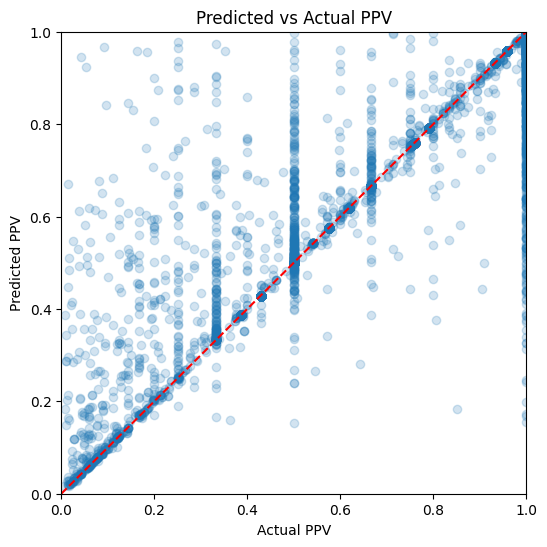

In [29]:
# let's run a random train test split first
X_baseline = final_ml.drop(columns=["resistant", "ppv", "drug"])
y_baseline = final_ml["ppv"]
print(y_baseline.isna().sum())

X_train, X_test, y_train, y_test = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=42)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2)
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Actual PPV")
plt.ylabel("Predicted PPV")
plt.title("Predicted vs Actual PPV")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()


In [30]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.0387139882083285
R2: 0.8419033375984704


### Let's change and do a mutation holdout to see if we can create a successful model that will predict PPV based on a new mutation

In [31]:
gene_key = final_ml.filter(like="gene_").idxmax(axis=1)
final_ml["mutation_key"] = gene_key + "_" + final_ml['position'].astype(str)

# features and the target
X = final_ml.drop(columns=["resistant", "ppv", "mutation_key"])
y = final_ml["ppv"]
group = final_ml["mutation_key"]

# Now we can use groupKFold to split the data
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=group)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train a simple model (e.g., Random Forest)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = model.predict(X_test)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

Fold 1
MAE: 0.05675594328831008
R2: 0.7311520514316148
Fold 2
MAE: 0.06157776667184003
R2: 0.7189023153859602
Fold 3
MAE: 0.05732189171260817
R2: 0.7189378237387893
Fold 4
MAE: 0.054387474166033165
R2: 0.745217076194429
Fold 5
MAE: 0.0544832395016691
R2: 0.752871949696772


## Add more positional data by downloading gene info

In [32]:
myco = pd.read_csv("Mycobacterium_tuberculosis_H37Rv_txt_v5.txt", sep="\t")
myco.columns = myco.columns.str.strip() # strip column names of whitespace
print(myco.columns)
print(myco.head())
myco['gene_length'] = myco['Stop'] - myco['Start'] + 1
myco_subset = myco[['Refseq_ID', 'Start', 'Stop', 'Name','gene_length']].copy()
myco_subset.head()

Index(['Refseq_ID', 'Mycobrowser_Version', 'Feature', 'Start', 'Stop', 'Score',
       'Strand', 'Frame', 'Locus', 'Name', 'Function', 'Product', 'Comments',
       'UniProt_AC', 'Is_Pseudogene', 'Functional_Category',
       'Protein Data Bank', 'PFAM', 'UniProt', 'Gene Ontology',
       'Enzyme Classification', 'Drug Resistance Mutations', 'InterPro',
       'UniProtKB/TrEMBL', 'SWISS-MODEL', 'Orthologues M. leprae',
       'Orthologues M. marinum', 'Orthologues M. smegmatis',
       'Orthologues M. bovis', 'Orthologues M. lepromatosis',
       'Orthologues M. tuberculosis', 'Orthologues M. abscessus',
       'Orthologues M. haemophilum', 'Orthologues M. orygis',
       'Orthologues M. tuberculosis.1'],
      dtype='object')
     Refseq_ID Mycobrowser_Version Feature   Start    Stop Score Strand  \
0  NC_000962.3      Mycobrowser_v5   ncRNA  759479  759610     .      +   
1  NC_000962.3      Mycobrowser_v5   ncRNA  786021  786074     .      +   
2  NC_000962.3      Mycobrowser_v5   n

,Refseq_ID,Start,Stop,Name,gene_length
0,NC_000962.3,759479,759610,ncRv10666,132
1,NC_000962.3,786021,786074,ncRv10685,54
2,NC_000962.3,80240,80440,ncRv10071,201
3,NC_000962.3,80254,80344,ncRv10071c,91
4,NC_000962.3,156452,156567,ncRv10128,116


In [33]:
new_data = final_ml.copy()
needed_genes = new_data.filter(like="gene_").columns.str.replace("gene_", "", regex=False)
print(needed_genes)

matched_myco = myco_subset[myco_subset['Name'].isin(needed_genes)].copy()
print(matched_myco)

Index(['PPE35', 'Rv0010c', 'Rv0565c', 'Rv0678', 'Rv1129c', 'Rv1258c',
       'Rv1979c', 'Rv2477c', 'Rv2681', 'Rv2752c', 'Rv2983', 'Rv3083',
       'Rv3236c', 'aftB', 'ahpC', 'bacA', 'ccsA', 'clpC1', 'ddn', 'dnaA',
       'eis', 'embA', 'embB', 'embC', 'embR', 'ethA', 'ethR', 'fbiA', 'fbiB',
       'fbiC', 'fgd1', 'gid', 'glpK', 'gyrA', 'gyrB', 'hadA', 'inhA', 'katG',
       'lpqB', 'mmpL5', 'mshA', 'mtrA', 'mtrB', 'ndh', 'nusG', 'panD', 'pepQ',
       'pncA', 'rplC', 'rpoA', 'rpoB', 'rpoC', 'rpsA', 'rpsL', 'rrl', 'rrs',
       'sigE', 'tlyA', 'tsnR', 'ubiA', 'whiB6', 'whiB7'],
      dtype='object')
        Refseq_ID    Start     Stop     Name  gene_length
132   NC_000962.3  1471846  1473382      rrs         1537
165   NC_000962.3        1     1524     dnaA         1524
169   NC_000962.3     7302     9818     gyrA         2517
174   NC_000962.3    13133    13558  Rv0010c          426
310   NC_000962.3   490783   491793     fgd1         1011
...           ...      ...      ...      ...  

In [34]:
gene_cols = [c for c in new_data.columns if c.startswith("gene_") and not c.startswith("gene_length")]
new_data['gene_name'] = new_data[gene_cols].idxmax(axis=1).str.replace("gene_", "", regex=False).str.lower()
matched_myco['gene_name'] = matched_myco['Name'].str.strip().str.lower()

new_data = new_data.merge(matched_myco[['gene_name', 'gene_length', 'Start', 'Stop']], on='gene_name', how='left')
new_data = new_data.drop(columns=['gene_name'])
new_data.head()

,ppv,drug,resistant,position,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,mutation_position,del_len,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,gene_length,Start,Stop
0,0.075644,0,0,2063685.0,0.0,0.0,0,0,1044.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063685.0,1920,2062809,2064728
1,0.075644,0,0,2063685.0,0.0,0.0,0,0,1044.0,0.0,...,False,False,False,False,True,False,gene_bacA_2063685.0,1920,2062809,2064728
2,1.000000,0,0,2063412.0,0.0,0.0,0,0,1317.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063412.0,1920,2062809,2064728
3,0.333333,0,0,2063358.0,0.0,0.0,0,0,1371.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063358.0,1920,2062809,2064728
4,0.035714,0,0,2063187.0,0.0,0.0,0,0,1542.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063187.0,1920,2062809,2064728


In [35]:
## add relative position of mutation in the gene
new_data['relative_position'] = (new_data['position'] - new_data['Start']) + 1
new_data['norm_position'] = new_data['relative_position'] / new_data['gene_length']
new_data = new_data.drop(columns=['Start', 'Stop'])
new_data.head()

,ppv,drug,resistant,position,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,mutation_position,del_len,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,gene_length,relative_position,norm_position
0,0.075644,0,0,2063685.0,0.0,0.0,0,0,1044.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063685.0,1920,877.0,0.456771
1,0.075644,0,0,2063685.0,0.0,0.0,0,0,1044.0,0.0,...,False,False,False,False,True,False,gene_bacA_2063685.0,1920,877.0,0.456771
2,1.000000,0,0,2063412.0,0.0,0.0,0,0,1317.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063412.0,1920,604.0,0.314583
3,0.333333,0,0,2063358.0,0.0,0.0,0,0,1371.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063358.0,1920,550.0,0.286458
4,0.035714,0,0,2063187.0,0.0,0.0,0,0,1542.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063187.0,1920,379.0,0.197396


In [36]:
## change to distances
new_data['distance_to_end'] = new_data['gene_length'] - new_data['relative_position']
new_data['codon_position'] = new_data['relative_position'] % 3
new_data = new_data.drop(columns=['relative_position', 'gene_length'])
new_data.head()

,ppv,drug,resistant,position,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,mutation_position,del_len,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,norm_position,distance_to_end,codon_position
0,0.075644,0,0,2063685.0,0.0,0.0,0,0,1044.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063685.0,0.456771,1043.0,1.0
1,0.075644,0,0,2063685.0,0.0,0.0,0,0,1044.0,0.0,...,False,False,False,False,True,False,gene_bacA_2063685.0,0.456771,1043.0,1.0
2,1.000000,0,0,2063412.0,0.0,0.0,0,0,1317.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063412.0,0.314583,1316.0,1.0
3,0.333333,0,0,2063358.0,0.0,0.0,0,0,1371.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063358.0,0.286458,1370.0,1.0
4,0.035714,0,0,2063187.0,0.0,0.0,0,0,1542.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063187.0,0.197396,1541.0,1.0


In [37]:
## drop the original position column since we have the relative position now
new_data_clean = new_data.copy()
new_data_clean = new_data_clean.drop(columns=['position'])
new_data_clean.head()

,ppv,drug,resistant,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,mutation_position,del_len,ins_len,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,norm_position,distance_to_end,codon_position
0,0.075644,0,0,0.0,0.0,0,0,1044.0,0.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063685.0,0.456771,1043.0,1.0
1,0.075644,0,0,0.0,0.0,0,0,1044.0,0.0,0.0,...,False,False,False,False,True,False,gene_bacA_2063685.0,0.456771,1043.0,1.0
2,1.000000,0,0,0.0,0.0,0,0,1317.0,0.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063412.0,0.314583,1316.0,1.0
3,0.333333,0,0,0.0,0.0,0,0,1371.0,0.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063358.0,0.286458,1370.0,1.0
4,0.035714,0,0,0.0,0.0,0,0,1542.0,0.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063187.0,0.197396,1541.0,1.0


In [38]:
X_old = final_ml.drop(columns=["ppv", "resistant", "mutation_key"], errors="ignore")
y = final_ml["ppv"]
groups = final_ml["mutation_key"]

X_new = new_data_clean.drop(columns=["ppv", "resistant", "mutation_key"], errors="ignore")
y_new = new_data_clean["ppv"]
groups_new = new_data_clean["mutation_key"]

gkf = GroupKFold(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_old, y, groups=groups)):
    print(f"Fold {fold + 1} - Old Data")
    X_train, X_test = X_old.iloc[train_idx], X_old.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    print("Old MAE:", mean_absolute_error(y_test, y_pred))
    print("Old R2:", r2_score(y_test, y_pred))


for fold, (train_idx, test_idx) in enumerate(gkf.split(X_new, y_new, groups=groups_new)):
    print(f"Fold {fold + 1} - New Data")
    X_train, X_test = X_new.iloc[train_idx], X_new.iloc[test_idx]
    y_train, y_test = y_new.iloc[train_idx], y_new.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("New MAE:", mean_absolute_error(y_test, y_pred))
    print("New R2:", r2_score(y_test, y_pred))



Fold 1 - Old Data
Old MAE: 0.05675594328831008
Old R2: 0.7311520514316148
Fold 2 - Old Data
Old MAE: 0.06157776667184003
Old R2: 0.7189023153859602
Fold 3 - Old Data
Old MAE: 0.05732189171260817
Old R2: 0.7189378237387893
Fold 4 - Old Data
Old MAE: 0.054387474166033165
Old R2: 0.745217076194429
Fold 5 - Old Data
Old MAE: 0.0544832395016691
Old R2: 0.752871949696772
Fold 1 - New Data
New MAE: 0.05960582794363125
New R2: 0.7180032899864981
Fold 2 - New Data
New MAE: 0.06260996281671366
New R2: 0.7276789388101415
Fold 3 - New Data
New MAE: 0.05826437745511715
New R2: 0.7254859857058749
Fold 4 - New Data
New MAE: 0.05556899754785217
New R2: 0.7494779582733009
Fold 5 - New Data
New MAE: 0.05684035941942921
New R2: 0.7443675337513727


In [44]:
# let's add bins
def ppv_bin(ppv):
    if ppv >= 0.8:
        return "3"
    elif ppv >= 0.6:
        return "2"
    elif ppv >= 0.2:
        return "1"
    else:
        return "0"

new_data_clean["ppv_bin"] = new_data_clean["ppv"].apply(ppv_bin)
new_data_clean.head()

,ppv,drug,resistant,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,mutation_position,del_len,ins_len,...,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,norm_position,distance_to_end,codon_position,ppv_bin
0,0.075644,0,0,0.0,0.0,0,0,1044.0,0.0,0.0,...,False,False,False,False,True,gene_bacA_2063685.0,0.456771,1043.0,1.0,0
1,0.075644,0,0,0.0,0.0,0,0,1044.0,0.0,0.0,...,False,False,False,True,False,gene_bacA_2063685.0,0.456771,1043.0,1.0,0
2,1.000000,0,0,0.0,0.0,0,0,1317.0,0.0,0.0,...,True,False,False,False,False,gene_bacA_2063412.0,0.314583,1316.0,1.0,3
3,0.333333,0,0,0.0,0.0,0,0,1371.0,0.0,0.0,...,False,False,False,False,True,gene_bacA_2063358.0,0.286458,1370.0,1.0,1
4,0.035714,0,0,0.0,0.0,0,0,1542.0,0.0,0.0,...,True,False,False,False,False,gene_bacA_2063187.0,0.197396,1541.0,1.0,0


In [45]:
from sklearn.ensemble import RandomForestClassifier

X = new_data_clean.drop(columns=["ppv", "ppv_bin", "resistant", "mutation_key", "drug"], errors="ignore")
y = new_data_clean["ppv_bin"]
groups = new_data_clean["mutation_key"]

gkf = GroupKFold(n_splits=5)
all_results = []
metrics = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    sample_weights = X_train["has_exact_mic"] * 3 + 1 + X_train["has_variant_mic"] * 2 # add some weights to samples with MIC data
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train, sample_weight=sample_weights)
    y_pred = model.predict(X_test)

    metrics.append({
        "fold": fold + 1,
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred)
    })

    fold_df = pd.DataFrame({
        "fold": fold + 1,
        "mutation": groups.iloc[test_idx].values,
        "actual": y_test.to_numpy(),
        "predicted": y_pred
    })

    all_results.append(fold_df)

    print(f"\nFold {fold+1}")
    print(classification_report(y_test, y_pred))
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred)}")

results_df = pd.concat(all_results, ignore_index=True)
metrics_df = pd.DataFrame(metrics)




Fold 1
              precision    recall  f1-score   support

           0       0.72      0.66      0.69       413
           1       0.88      0.88      0.88      2586
           2       0.96      0.92      0.94      1494
           3       0.86      0.89      0.87      2626

    accuracy                           0.88      7119
   macro avg       0.85      0.84      0.84      7119
weighted avg       0.88      0.88      0.88      7119

Balanced Accuracy: 0.8363670041498041

Fold 2
              precision    recall  f1-score   support

           0       0.71      0.60      0.65       451
           1       0.86      0.84      0.85      2445
           2       0.95      0.90      0.92      1539
           3       0.83      0.89      0.86      2684

    accuracy                           0.86      7119
   macro avg       0.84      0.81      0.82      7119
weighted avg       0.86      0.86      0.86      7119

Balanced Accuracy: 0.8089014237569534

Fold 3
              precision    rec

In [46]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    
    print(f"\n=== Fold {fold+1} ===")
    
    # unseen mutations in this fold
    test_mutations = groups.iloc[test_idx].unique()
    
    print(f"Number of unseen mutations: {len(test_mutations)}")
    print("Sample mutations:")
    print(test_mutations[:10])  # print first 10


=== Fold 1 ===
Number of unseen mutations: 2426
Sample mutations:
['gene_bacA_2062881.0' 'gene_bacA_2063911.0' 'gene_ccsA_620280.0'
 'gene_ccsA_620316.0' 'gene_ccsA_620553.0' 'gene_ccsA_619962.0'
 'gene_eis_2715345.0' 'gene_eis_2714846.0' 'gene_rrs_1472892.0'
 'gene_rrs_1473053.0']

=== Fold 2 ===
Number of unseen mutations: 2427
Sample mutations:
['gene_bacA_2063412.0' 'gene_bacA_2063358.0' 'gene_bacA_2064177.0'
 'gene_ccsA_620029.0' 'gene_ccsA_620358.0' 'gene_eis_2715342.0'
 'gene_eis_2714172.0' 'gene_eis_2715126.0' 'gene_eis_2715291.0'
 'gene_rrs_1473061.0']

=== Fold 3 ===
Number of unseen mutations: 2426
Sample mutations:
['gene_bacA_2063106.0' 'gene_bacA_2062922.0' 'gene_ccsA_620397.0'
 'gene_ccsA_620619.0' 'gene_ccsA_620625.0' 'gene_ccsA_619965.0'
 'gene_ccsA_619969.0' 'gene_eis_2715344.0' 'gene_rrs_1472895.0'
 'gene_rrs_1473034.0']

=== Fold 4 ===
Number of unseen mutations: 2427
Sample mutations:
['gene_bacA_2063685.0' 'gene_bacA_2063187.0' 'gene_bacA_2062947.0'
 'gene_bacA_2

In [47]:
results_df.head()

,fold,mutation,actual,predicted
0,1,gene_bacA_2062881.0,3,1
1,1,gene_bacA_2063911.0,0,0
2,1,gene_ccsA_620280.0,0,0
3,1,gene_ccsA_620316.0,3,0
4,1,gene_ccsA_620316.0,3,0


In [48]:
results_df["correct"] = results_df["actual"] == results_df["predicted"]
print(results_df["correct"].mean())

0.8711789166104743


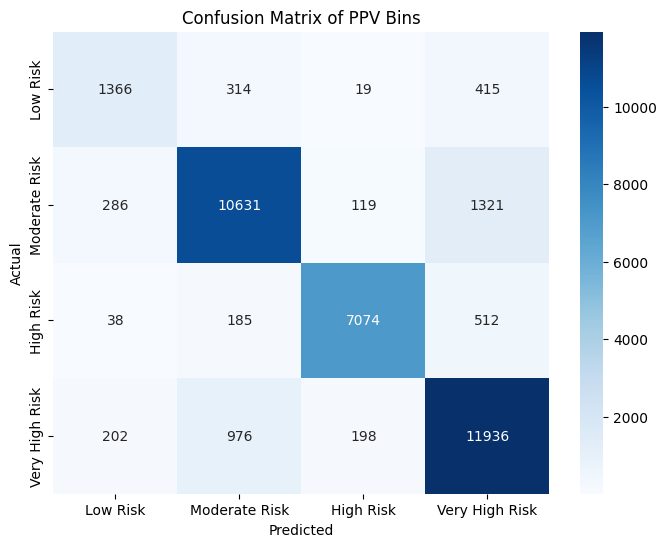

In [49]:
# let's look plot the distribution of predicted vs actual for each class as a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(results_df["actual"], results_df["predicted"], labels=["0", "1", "2", "3"])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"],
            yticklabels=["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of PPV Bins")
plt.show()


## Advanced Model Exploration: Boosting Algorithms
As a scientific follow-up to the Random Forest baseline, we explore several state-of-the-art boosting algorithms: **AdaBoost**, **XGBoost**, **LightGBM**, and **CatBoost**.

Our hypothesis is that these gradient boosting methods can better capture complex interactions between genetic mutations and drug structures, potentially leading to improved predictive performance for Positive Predictive Value (PPV) bins.

We maintain the same **GroupKFold** cross-validation strategy (grouping by `mutation_key`) to ensure fair comparison and prevent data leakage.

In [51]:
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from sklearn.model_selection import GroupKFold
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Prepare data (same as cell 39)
X = new_data_clean.drop(columns=["ppv", "ppv_bin", "resistant", "mutation_key", "drug"], errors="ignore")
y = new_data_clean["ppv_bin"]
groups = new_data_clean["mutation_key"]

# Impute columns with many NaNs
X['mutation_position'] = X['mutation_position'].fillna(-1)
X['del_len'] = X['del_len'].fillna(0)
X['ins_len'] = X['ins_len'].fillna(0)

print("NaN counts before dropping:")
print(X.isna().sum()[X.isna().sum() > 0])

# Drop rows with NaNs in remaining columns
nan_mask = X.isna().any(axis=1)
print(f"Dropping {nan_mask.sum()} rows containing remaining NaN values.")
X = X[~nan_mask]
y = y[~nan_mask]
groups = groups[~nan_mask]

# ppv_bin is already 0-indexed ("0".."3") — just cast to int
y = y.astype(int) 

gkf = GroupKFold(n_splits=5)

models = {
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=False)
}

all_model_results = []

for model_name, clf in models.items():
    print(f"\n==================== Evaluating {model_name} ====================")
    fold_results = []
    
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Sample weights as in cell 39
        sample_weights = X_train["has_exact_mic"] * 3 + 1 + X_train["has_variant_mic"] * 2
        
        if model_name == "CatBoost":
            clf.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)
        else: # AdaBoost, XGBoost, LightGBM
            clf.fit(X_train, y_train, sample_weight=sample_weights)
            
        y_pred = clf.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        
        fold_results.append({
            "Model": model_name,
            "Fold": fold + 1,
            "Accuracy": acc,
            "Balanced_Accuracy": bal_acc
        })
        
    fold_df = pd.DataFrame(fold_results)
    print(f"Mean Accuracy: {fold_df['Accuracy'].mean():.4f}")
    print(f"Mean Balanced Accuracy: {fold_df['Balanced_Accuracy'].mean():.4f}")
    
    all_model_results.append(fold_df)

summary_df = pd.concat(all_model_results, ignore_index=True)

NaN counts before dropping:
norm_position      4
distance_to_end    4
codon_position     4
dtype: int64
Dropping 4 rows containing remaining NaN values.

==================== Evaluating AdaBoost ====================
Mean Accuracy: 0.7424
Mean Balanced Accuracy: 0.6564

==================== Evaluating XGBoost ====================
Mean Accuracy: 0.8782
Mean Balanced Accuracy: 0.8230

==================== Evaluating LightGBM ====================
Mean Accuracy: 0.8789
Mean Balanced Accuracy: 0.8235

==================== Evaluating CatBoost ====================
Mean Accuracy: 0.8754
Mean Balanced Accuracy: 0.8218


In [53]:
# Summarize and compare results
print("\nSummary of Model Performance (Averaged over 5 Folds):")
pivot_df = summary_df.groupby("Model")[["Accuracy", "Balanced_Accuracy"]].mean().reset_index()
print(pivot_df.sort_values(by="Accuracy", ascending=False))

print("\nRandom Forest Baseline Accuracy (from previous run): ", results_df["correct"].mean())


Summary of Model Performance (Averaged over 5 Folds):
      Model  Accuracy  Balanced_Accuracy
2  LightGBM  0.878920           0.823504
3   XGBoost  0.878190           0.823015
1  CatBoost  0.875436           0.821837
0  AdaBoost  0.742357           0.656359

Random Forest Baseline Accuracy (from previous run):  0.8711789166104743
